# Axelrod Examples: Playing Matches and Plotting Results

In [43]:
# Python 3
%matplotlib inline

import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import axelrod as axl

plt.rcParams['figure.figsize'] = (10, 10)

# Matches

Let's try out some some simulated matches between two opponents and plot the score distributions. To make this interesting we should choose stochastic strategies. First we generate some matches between the players, score the results, and plot them per turn.

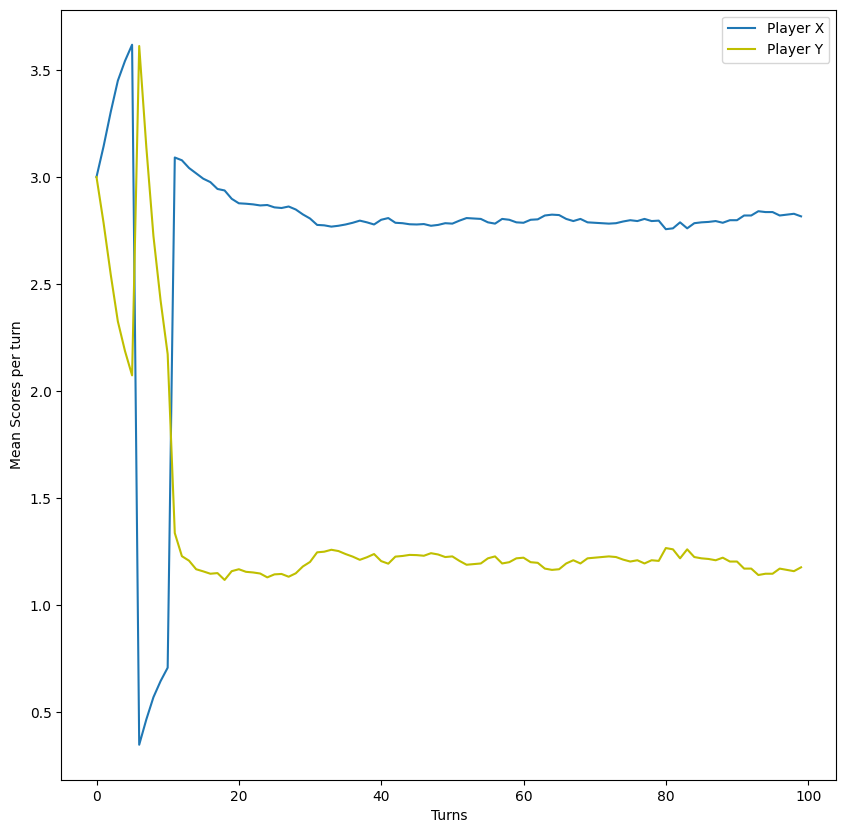

In [44]:
# Two Zero-Determinant Strategies
# player1 = axl.ZDGTFT2()
# player2 = axl.ZDSet2()

player1 = axl.ZDExtortion(phi=0.0476 ) # X = 5  
player2 = axl.Adaptive()

turns = 100
matches = 1000 # repeated

scores = []
for i in range(matches):
    match = axl.Match((player1, player2), turns)
    results = match.play()
    scores.append(list(zip(*match.scores())))

scores1, scores2 = zip(*scores)


plt.plot(np.mean(scores1, axis=0), label='Player X')
plt.plot(np.mean(scores2, axis=0), color="y", label='Player Y')
plt.xlabel("Turns")
plt.ylabel("Mean Scores per turn")
plt.legend()

Now let's look at the end results for each strategy. We'll take the average score for each player over many matches and plot the resulting distributions

Text(0.5, 0, 'Players')

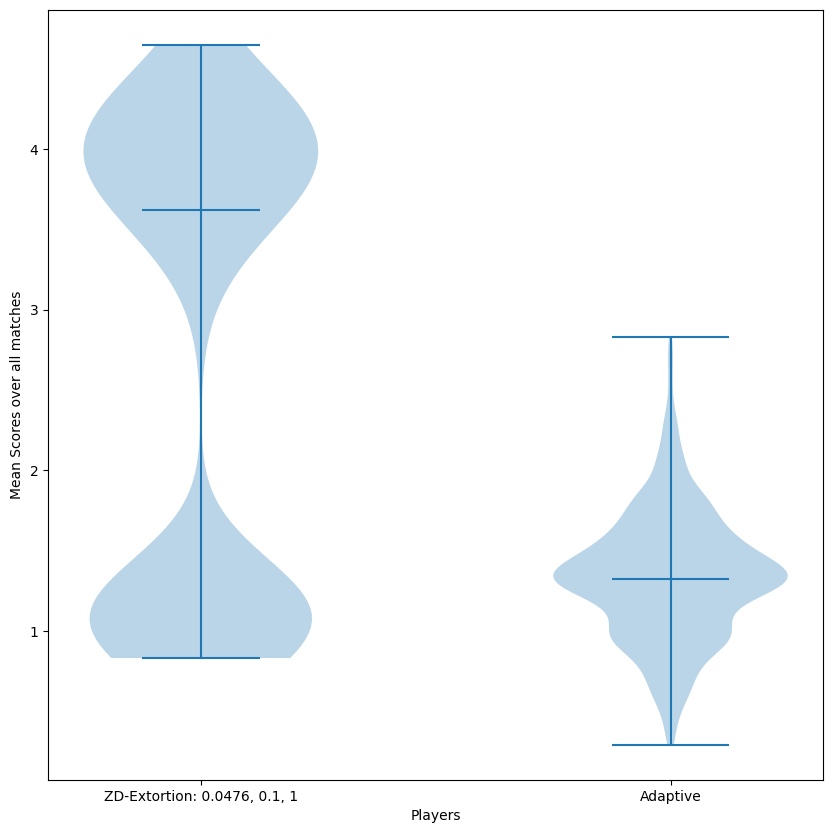

In [45]:
# Two Zero-Determinant Strategies
# player1 = axl.ZDGTFT2()
# player2 = axl.ZDSet2()

scores = []

for i in range(matches):
    match = axl.Match((player1, player2), turns)
    results = match.play()
    # Sum the scores from the match for each player
    scores.append(np.sum(match.scores(), axis=0) / float(turns))    

df = pd.DataFrame(scores)
df.columns = ["Player1", "Player2"]
df.mean()

plt.violinplot(df[["Player1", "Player2"]].values, showmedians=True)
plt.xticks([1,2], [str(player1), str(player2)])
plt.ylabel("Mean Scores over all matches")
plt.xlabel("Players")

# Noisy Matches
Let's see how a little stochastic noise affects these plots. Without noise these next two strategies would always cooperate, and so both always score 3 points in each round. Instead they are driven toward mutual defection.

/home/vince/anaconda3/lib/python3.5/site-packages/seaborn/timeseries.py:183: UserWarning: The tsplot function is deprecated and will be removed or replaced (in a substantially altered version) in a future release.
  warnings.warn(msg, UserWarning)


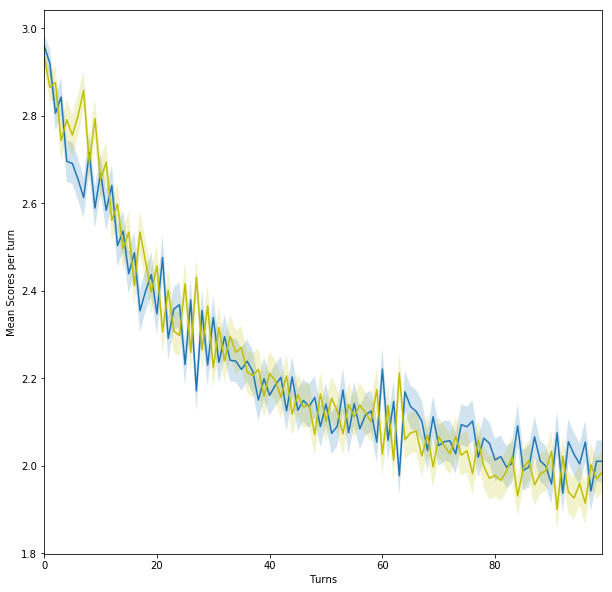

In [4]:
# Two typically deterministic strategies
player1 = axl.OmegaTFT()
player2 = axl.TitForTat()

scores = []
for i in range(matches):
    match = axl.Match((player1, player2), turns, noise=0.05) # 5% noise
    results = match.play()
    scores.append(list(zip(*match.scores())))

scores1, scores2 = zip(*scores)

sns.tsplot(scores1)
sns.tsplot(scores2, color="y")
plt.xlabel("Turns")
plt.ylabel("Mean Scores per turn")

Here we see that WinStayLoseShift is able to recover from the occasional defection due to noise to maintain mutual cooperation.

/home/vince/anaconda3/lib/python3.5/site-packages/seaborn/timeseries.py:183: UserWarning: The tsplot function is deprecated and will be removed or replaced (in a substantially altered version) in a future release.
  warnings.warn(msg, UserWarning)


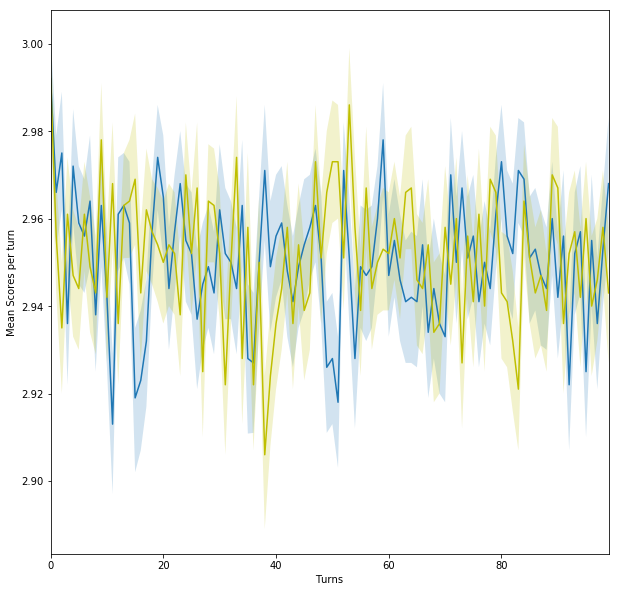

In [5]:
# Two typically deterministic strategies
player1 = axl.WinStayLoseShift()
player2 = axl.WinStayLoseShift()

scores = []
for i in range(matches):
    match = axl.Match((player1, player2), turns, noise=0.01) # 5% noise
    results = match.play()
    scores.append(list(zip(*match.scores())))

scores1, scores2 = zip(*scores)

sns.tsplot(scores1)
sns.tsplot(scores2, color="y")
plt.xlabel("Turns")
plt.ylabel("Mean Scores per turn")

# Tournament

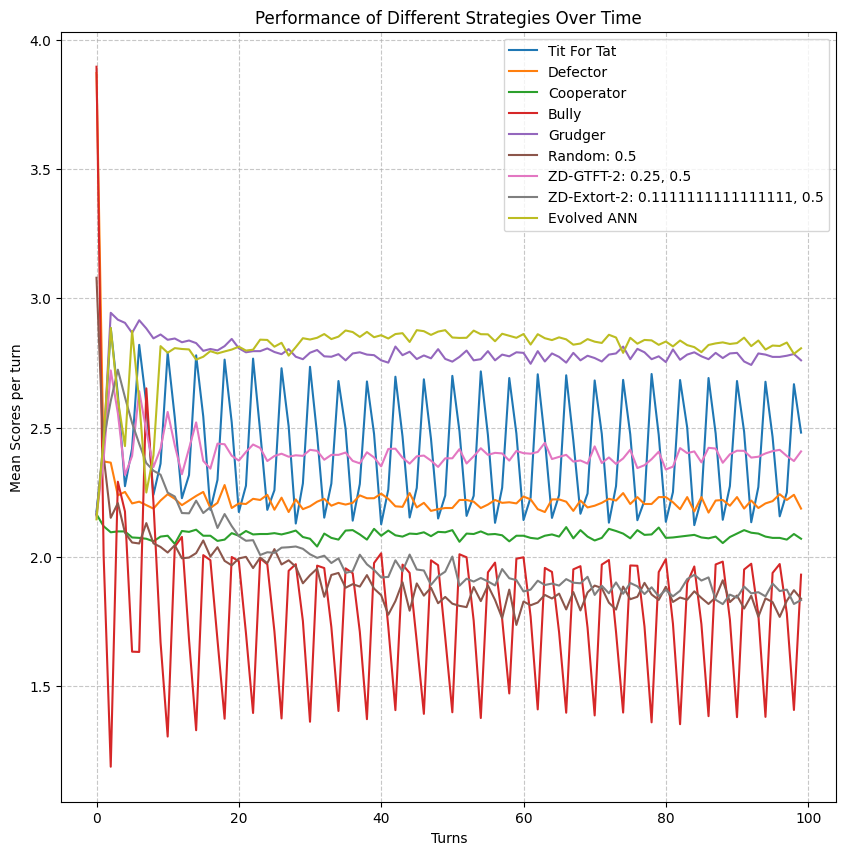

In [46]:
import axelrod as axl
import matplotlib.pyplot as plt
import numpy as np

strategies = [
    axl.TitForTat(),
    axl.Defector(),
    axl.Cooperator(),
    axl.Bully(),
    axl.Grudger(),  # Grim
    axl.Random(),
    axl.ZDGTFT2(),
    axl.ZDExtort2(),
    axl.EvolvedANN()
]


turns = 100
matches_per_pair = 200  # Number of matches for each pair of players

# Dictionary to store scores for each player over turns
player_scores = {str(player): [] for player in strategies}

# Play matches between all pairs of players
for i, player1 in enumerate(strategies):
    for player2 in strategies[i:]:  # Only play each pair once
        for _ in range(matches_per_pair):
            match = axl.Match((player1, player2), turns=turns)
            match.play()
            p1_scores, p2_scores = zip(*match.scores())
            
            # Store the scores per turn
            if str(player1) in player_scores:
                if not player_scores[str(player1)]:
                    player_scores[str(player1)] = [[] for _ in range(turns)]
                for t in range(turns):
                    player_scores[str(player1)][t].append(p1_scores[t])
            
            if player1 != player2 and str(player2) in player_scores:
                if not player_scores[str(player2)]:
                    player_scores[str(player2)] = [[] for _ in range(turns)]
                for t in range(turns):
                    player_scores[str(player2)][t].append(p2_scores[t])

# Calculate mean scores per turn for each player
mean_scores = {}
for player, scores_by_turn in player_scores.items():
    mean_scores[player] = [np.mean(turn_scores) for turn_scores in scores_by_turn]

# Plot results
plt.figure(figsize=(10, 10))
for player, scores in mean_scores.items():
    plt.plot(scores, label=player)

plt.xlabel("Turns")
plt.ylabel("Mean Scores per turn")
plt.title("Performance of Different Strategies Over Time")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Analysing: 100%|██████████| 25/25 [00:00<00:00, 246.05it/s]


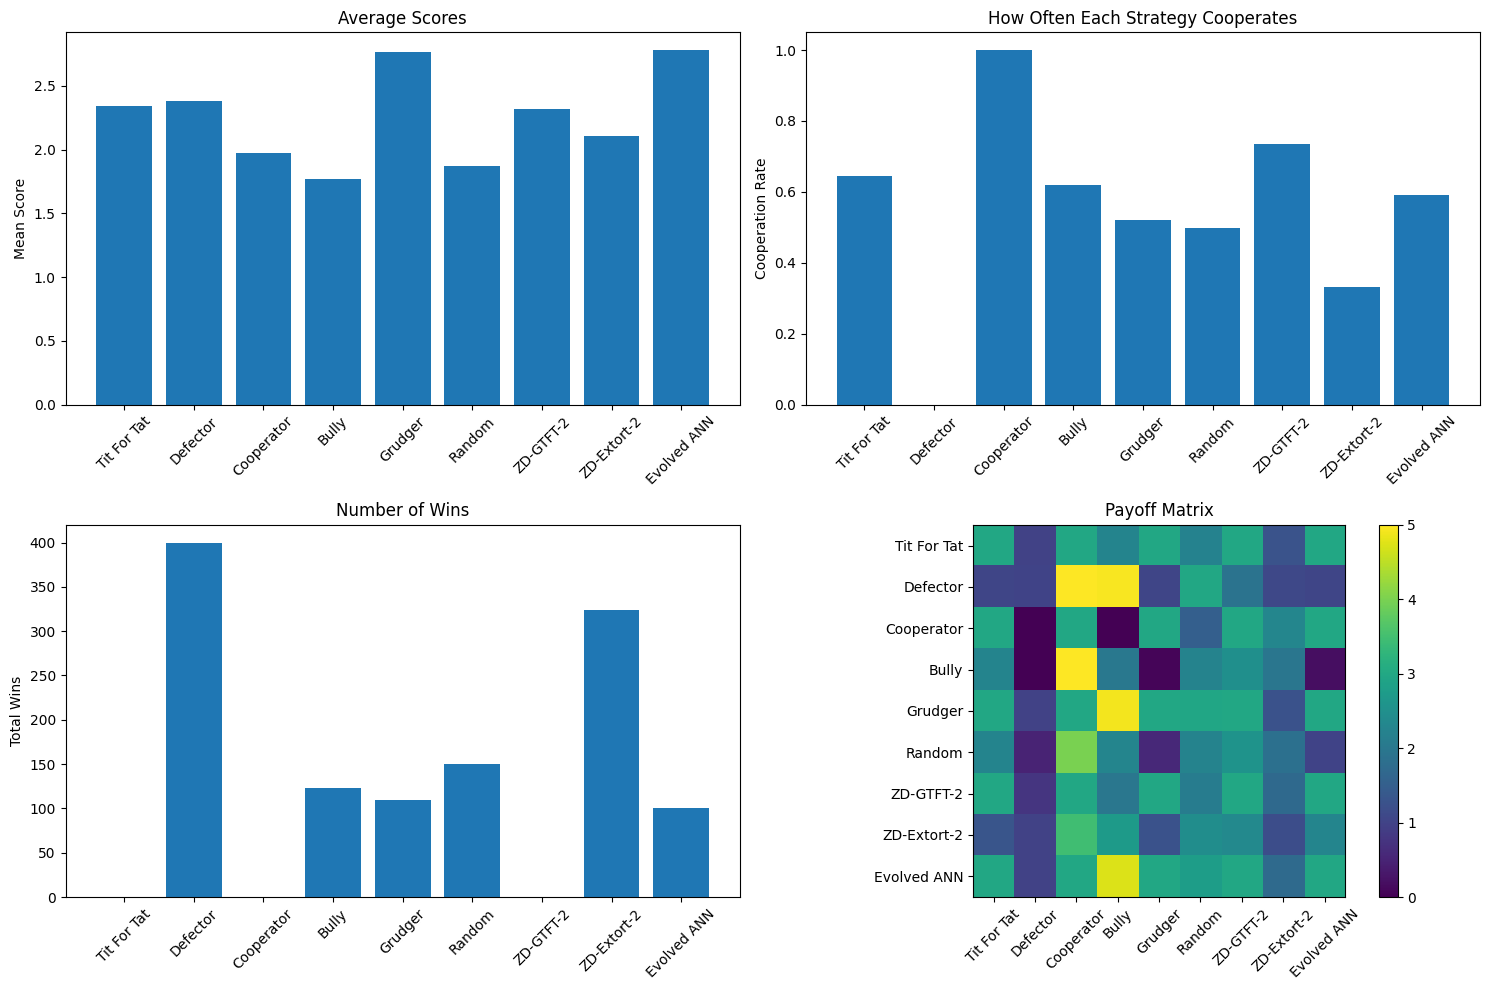

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import axelrod as axl

# Define multiple players
players = [
    axl.TitForTat(),
    axl.Defector(),
    axl.Cooperator(),
    axl.Bully(),
    axl.Grudger(),  # Grim
    axl.Random(),
    axl.ZDGTFT2(),
    axl.ZDExtort2(),
    axl.EvolvedANN()
]

# Set up a tournament
tournament = axl.Tournament(players, turns=100, repetitions=50)
results = tournament.play()

# Plot various metrics
plt.figure(figsize=(15, 10))

# Plot 1: Scores - Average across repetitions
plt.subplot(2, 2, 1)
scores = results.normalised_scores
plt.bar(range(len(players)), np.mean(scores, axis=1))
plt.xticks(range(len(players)), [p.name for p in players], rotation=45)
plt.ylabel("Mean Score")
plt.title("Average Scores")

# Plot 2: Cooperation rates
plt.subplot(2, 2, 2)
cooperation = np.array(results.cooperating_rating)
plt.bar(range(len(players)), cooperation)
plt.xticks(range(len(players)), [p.name for p in players], rotation=45)
plt.ylabel("Cooperation Rate")
plt.title("How Often Each Strategy Cooperates")

# Plot 3: Wins - Sum across repetitions
plt.subplot(2, 2, 3)
wins = np.sum(results.wins, axis=1)  # Sum wins across all repetitions
plt.bar(range(len(players)), wins)
plt.xticks(range(len(players)), [p.name for p in players], rotation=45)
plt.ylabel("Total Wins")
plt.title("Number of Wins")

# Plot 4: Payoff matrix (already averaged)
plt.subplot(2, 2, 4)
plt.imshow(results.payoff_matrix, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(players)), [p.name for p in players], rotation=45)
plt.yticks(range(len(players)), [p.name for p in players])
plt.title("Payoff Matrix")

plt.tight_layout()